Directorio: /home/jovyan/work/scrapers
Documentos cargados: 3679
Columnas: ['dormitorios', 'tipo_inmueble', 'estacionamiento', 'tipo_interes', 'banco', 'monto', 'cae', 'region', 'pie', 'extractor', 'date', 'url_fuente', 'ubicacion_detalle', 'titulo_proyecto', 'id_registro', 'cae_origen', 'escenario_financiamiento', 'fuente', 'integrante', 'monto_financiado_uf', 'monto_pie_uf', 'plazo_anios', 'tipo_registro', 'url_pagina_scrapeada', 'periodo']

=== VOLUMEN POR EXTRACTOR ===
    extractor  documentos estado
     fernanda          49 FALTAN
joaquin_serey         973     OK
         juan         932     OK
     millaray         600     OK
          pia         599     OK
 ruben_cortes         526     OK

Total: 3679 documentos

=== LIMPIEZA ===
Originales:  3679
Eliminados:  1210
Finales:     2469

=== VALORES NULOS ===
ubicacion_detalle           1766
titulo_proyecto             2287
id_registro                 2412
cae_origen                  2412
escenario_financiamiento    2412
fuente 

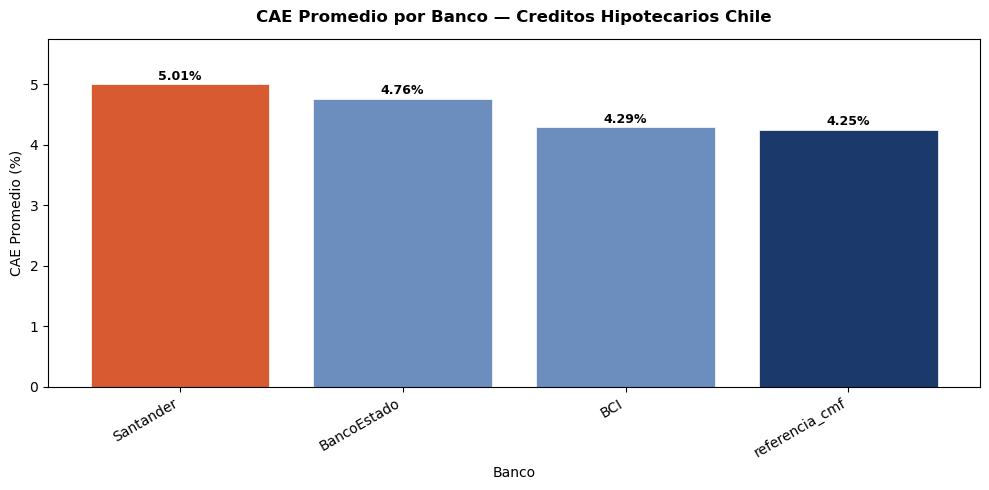

Guardado: data/grafico1_cae_por_banco.png


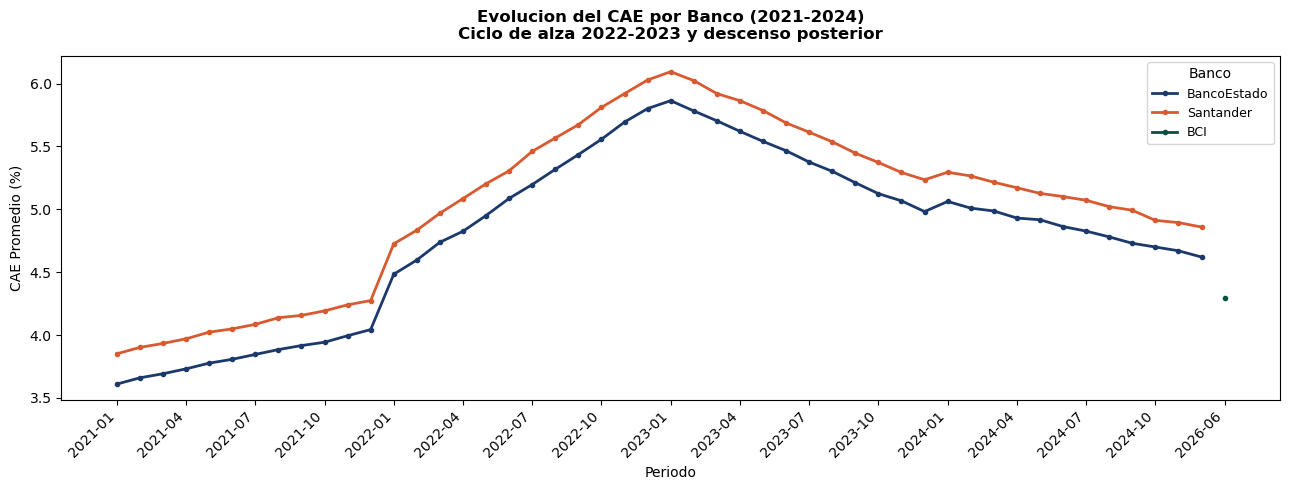

Guardado: data/grafico2_evolucion_cae.png


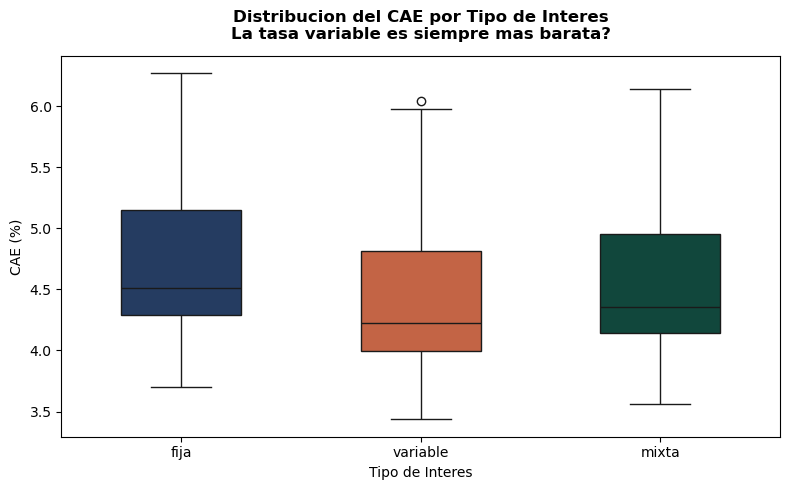

Guardado: data/grafico3_boxplot_tipo_interes.png


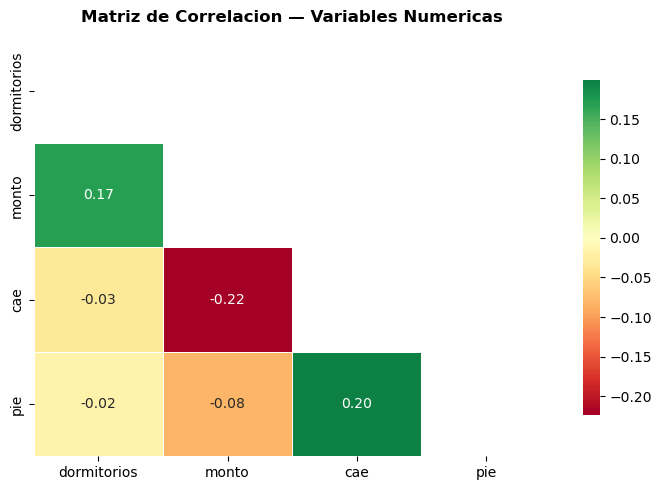

Guardado: data/grafico4_correlacion.png


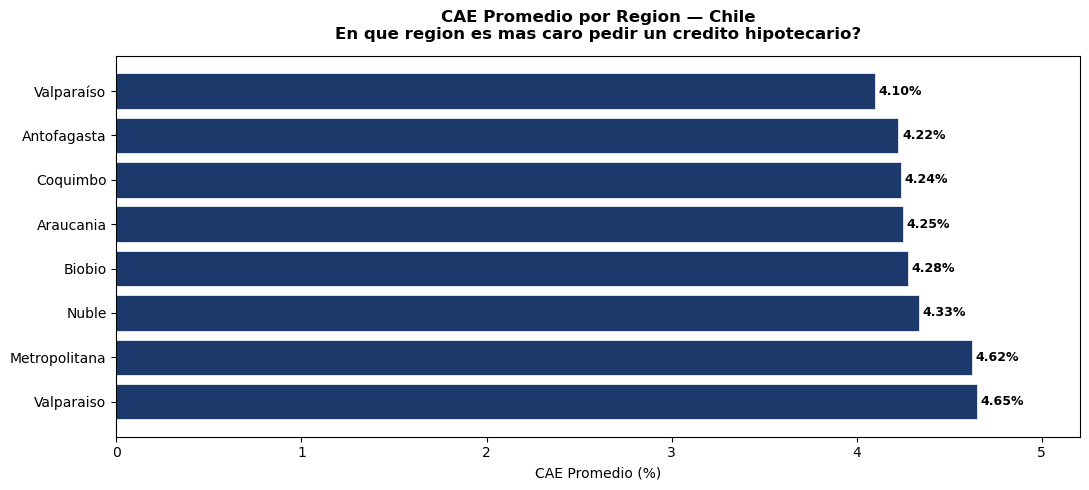

Guardado: data/grafico5_cae_por_region.png

=== INGENIERIA DE VARIABLES ===
Variables creadas:
  variacion_mensual: 2385 valores
  tendencia: 2469 valores
  sube_cae: 2469 valores
  cuota_estimada: 2469 valores
  desviacion_vs_banco: 2469 valores

Variable Y (sube_cae):
  No sube (0): 1264 (51.2%)
  Sube (1): 1205 (48.8%)


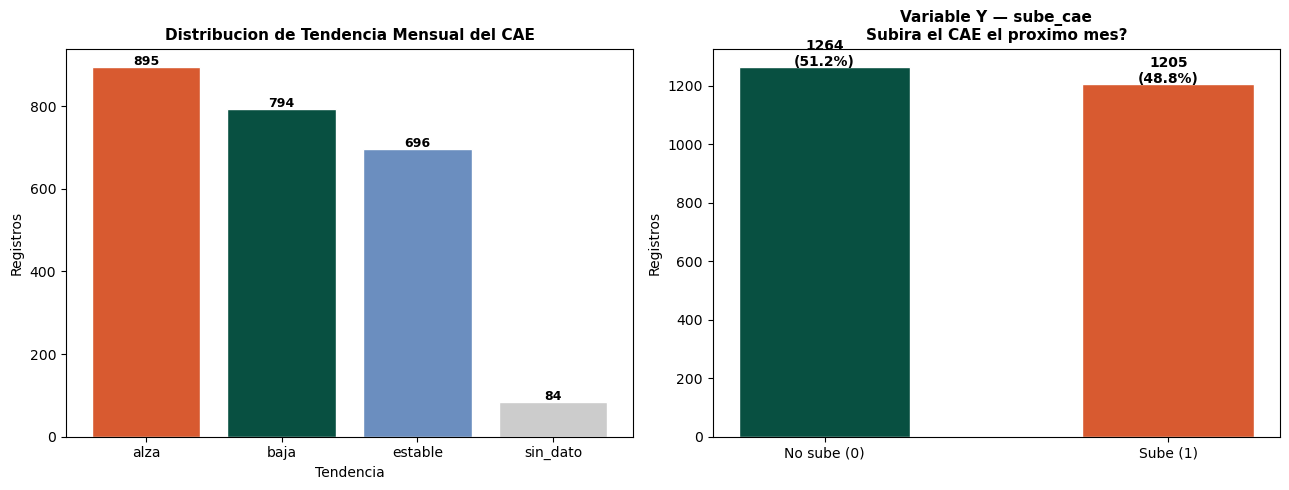

Guardado: data/grafico6_tendencia_variableY.png

=== GUARDANDO processed_data EN ATLAS ===
processed_data: 2469 documentos

  TICKET DE SALIDA — ENTREGA 2
  raw_data:        3679 documentos
  processed_data:  2469 documentos

  Variables derivadas creadas (5):
    variacion_mensual, tendencia, sube_cae,
    cuota_estimada, desviacion_vs_banco

  Variable Y: sube_cae (0=no sube / 1=sube)

  Graficos guardados en data/:
    1. grafico1_cae_por_banco.png
    2. grafico2_evolucion_cae.png
    3. grafico3_boxplot_tipo_interes.png
    4. grafico4_correlacion.png
    5. grafico5_cae_por_region.png
    6. grafico6_tendencia_variableY.png

Entrega 2 completada


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi

warnings.filterwarnings("ignore")

# ── RUTA CORRECTA PARA DOCKER ────────────────────────────────────
os.chdir("/home/jovyan/work/scrapers")
os.makedirs("data", exist_ok=True)
print(f"Directorio: {os.getcwd()}")

# ── CONEXIÓN A ATLAS ─────────────────────────────────────────────
USUARIO  = "joaquinserey_db_user"
PASSWORD = "joaquin3001"
HOST     = "datatreaders.xake49k.mongodb.net"
DB       = "HipotecarioChile"

URI = (f"mongodb+srv://{USUARIO}:{PASSWORD}@{HOST}/{DB}"
       f"?retryWrites=true&w=majority&appName=DataTraders")

client = MongoClient(URI, tlsCAFile=certifi.where())
col    = client[DB]["datos_hipotecarios"]

docs = list(col.find({}, {"_id": 0, "nota": 0, "timestamp": 0}))
df   = pd.DataFrame(docs)

print(f"Documentos cargados: {len(df)}")
print(f"Columnas: {list(df.columns)}")


# ── VOLUMEN POR EXTRACTOR ────────────────────────────────────────
print("\n=== VOLUMEN POR EXTRACTOR ===")
conteo = df.groupby("extractor").size().reset_index(name="documentos")
conteo["estado"] = conteo["documentos"].apply(
    lambda n: "OK" if n >= 500 else "FALTAN"
)
print(conteo.to_string(index=False))
print(f"\nTotal: {len(df)} documentos")


# ── LIMPIEZA ─────────────────────────────────────────────────────
print("\n=== LIMPIEZA ===")
n_inicial = len(df)

df["dormitorios"]     = pd.to_numeric(df["dormitorios"],    errors="coerce")
df["monto"]           = pd.to_numeric(df["monto"],          errors="coerce")
df["cae"]             = pd.to_numeric(df["cae"],            errors="coerce")
df["pie"]             = pd.to_numeric(df["pie"],            errors="coerce")
df["estacionamiento"] = df["estacionamiento"].astype(bool)
df["date"]            = pd.to_datetime(df["date"],          errors="coerce")

df = df.drop_duplicates(
    subset=["extractor","monto","dormitorios","region","tipo_interes","date"]
)
df = df.dropna(subset=["cae","monto","dormitorios","region","banco"])

q1, q3 = df["cae"].quantile([0.25, 0.75])
iqr = q3 - q1
df  = df[(df["cae"] >= q1 - 3*iqr) & (df["cae"] <= q3 + 3*iqr)]

q1m, q3m = df["monto"].quantile([0.25, 0.75])
iqrm = q3m - q1m
df   = df[(df["monto"] >= q1m - 3*iqrm) & (df["monto"] <= q3m + 3*iqrm)]

print(f"Originales:  {n_inicial}")
print(f"Eliminados:  {n_inicial - len(df)}")
print(f"Finales:     {len(df)}")


# ── ANÁLISIS DE NULOS ────────────────────────────────────────────
print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Sin valores nulos" if len(nulos) == 0 else nulos)


# ── ESTADÍSTICAS POR BANCO ───────────────────────────────────────
print("\n=== ESTADISTICAS CAE POR BANCO ===")
stats = df.groupby("banco")["cae"].agg(
    media="mean", desv_std="std",
    minimo="min", maximo="max", n="count"
).round(4).sort_values("media", ascending=False)
print(stats.to_string())


# ── GRÁFICO 1: CAE promedio por banco ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bancos_data = df.groupby("banco")["cae"].mean().sort_values(ascending=False)
colores = ["#D85A30" if v == bancos_data.max()
           else "#1B3A6B" if v == bancos_data.min()
           else "#6B8EBF" for v in bancos_data.values]
bars = ax.bar(bancos_data.index, bancos_data.values,
              color=colores, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, bancos_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.2f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("CAE Promedio por Banco — Creditos Hipotecarios Chile",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Banco")
ax.set_ylabel("CAE Promedio (%)")
ax.set_ylim(0, bancos_data.max() * 1.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("data/grafico1_cae_por_banco.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: data/grafico1_cae_por_banco.png")


# ── GRÁFICO 2: Evolución CAE en el tiempo ────────────────────────
df_tiempo = df[df["date"].notna()].copy()
df_tiempo["periodo"] = df_tiempo["date"].dt.to_period("M").astype(str)
bancos_reales = [b for b in ["BancoEstado","Santander","BCI"]
                 if b in df_tiempo["banco"].unique()]

if bancos_reales:
    evol = df_tiempo[df_tiempo["banco"].isin(bancos_reales)] \
           .groupby(["periodo","banco"])["cae"].mean() \
           .reset_index().sort_values("periodo")

    fig, ax = plt.subplots(figsize=(13, 5))
    colores_b = {"BancoEstado":"#1B3A6B","Santander":"#D85A30","BCI":"#085041"}
    for banco in bancos_reales:
        sub = evol[evol["banco"] == banco]
        ax.plot(sub["periodo"], sub["cae"], label=banco, linewidth=2,
                color=colores_b.get(banco,"gray"), marker="o", markersize=3)
    periodos = evol["periodo"].unique()
    ax.set_xticks(range(0, len(periodos), 3))
    ax.set_xticklabels(periodos[::3], rotation=45, ha="right")
    ax.set_title("Evolucion del CAE por Banco (2021-2024)\n"
                 "Ciclo de alza 2022-2023 y descenso posterior",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("CAE Promedio (%)")
    ax.legend(title="Banco", fontsize=9)
    plt.tight_layout()
    plt.savefig("data/grafico2_evolucion_cae.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado: data/grafico2_evolucion_cae.png")


# ── GRÁFICO 3: Boxplot CAE por tipo de interés ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
orden = [t for t in ["fija","variable","mixta"]
         if t in df["tipo_interes"].unique()]
sns.boxplot(data=df, x="tipo_interes", y="cae", order=orden,
            palette=["#1B3A6B","#D85A30","#085041"], ax=ax, width=0.5)
ax.set_title("Distribucion del CAE por Tipo de Interes\n"
             "La tasa variable es siempre mas barata?",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Tipo de Interes")
ax.set_ylabel("CAE (%)")
plt.tight_layout()
plt.savefig("data/grafico3_boxplot_tipo_interes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: data/grafico3_boxplot_tipo_interes.png")


# ── GRÁFICO 4: Heatmap de correlación ────────────────────────────
cols_num = [c for c in ["dormitorios","monto","cae","pie"] if c in df.columns]
corr = df[cols_num].corr()
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de Correlacion — Variables Numericas",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("data/grafico4_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: data/grafico4_correlacion.png")


# ── GRÁFICO 5: CAE por región ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
region_data = df.groupby("region")["cae"].mean().sort_values(ascending=False)
ax.barh(region_data.index, region_data.values,
        color="#1B3A6B", edgecolor="white", linewidth=0.5)
for i, (region, val) in enumerate(region_data.items()):
    ax.text(val + 0.02, i, f"{val:.2f}%", va="center",
            fontsize=9, fontweight="bold")
ax.set_title("CAE Promedio por Region — Chile\n"
             "En que region es mas caro pedir un credito hipotecario?",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("CAE Promedio (%)")
ax.set_xlim(0, region_data.max() * 1.12)
plt.tight_layout()
plt.savefig("data/grafico5_cae_por_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: data/grafico5_cae_por_region.png")


# ── INGENIERÍA DE VARIABLES ──────────────────────────────────────
print("\n=== INGENIERIA DE VARIABLES ===")
df = df.sort_values(["banco","tipo_interes","region","dormitorios","date"])

# Variable 1: variacion_mensual
df["variacion_mensual"] = df.groupby(
    ["banco","tipo_interes","region","dormitorios"]
)["cae"].diff().round(4)

# Variable 2: tendencia
def tendencia(v):
    if pd.isna(v):  return "sin_dato"
    if v > 0.05:    return "alza"
    if v < -0.05:   return "baja"
    return "estable"
df["tendencia"] = df["variacion_mensual"].apply(tendencia)

# Variable 3: sube_cae — VARIABLE Y
df["sube_cae"] = df.groupby(
    ["banco","tipo_interes","region","dormitorios"]
)["variacion_mensual"].shift(-1).apply(
    lambda v: 1.0 if (not pd.isna(v) and v > 0) else 0.0
)

# Variable 4: cuota_estimada
df["cuota_estimada"] = (df["monto"] * (df["cae"]/100) / 12).round(2)

# Variable 5: desviacion_vs_banco
media_banco = df.groupby("banco")["cae"].transform("mean")
df["desviacion_vs_banco"] = (df["cae"] - media_banco).round(4)

print("Variables creadas:")
for v in ["variacion_mensual","tendencia","sube_cae",
          "cuota_estimada","desviacion_vs_banco"]:
    print(f"  {v}: {df[v].notna().sum()} valores")

print(f"\nVariable Y (sube_cae):")
dist = df["sube_cae"].value_counts()
for val, n in dist.items():
    print(f"  {'Sube' if val==1.0 else 'No sube'} ({int(val)}): "
          f"{n} ({n/len(df)*100:.1f}%)")


# ── GRÁFICO 6: Tendencia y Variable Y ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tend_count = df["tendencia"].value_counts()
colores_t  = {"alza":"#D85A30","baja":"#085041",
              "estable":"#6B8EBF","sin_dato":"#CCCCCC"}
axes[0].bar(tend_count.index, tend_count.values,
            color=[colores_t.get(t,"gray") for t in tend_count.index],
            edgecolor="white")
axes[0].set_title("Distribucion de Tendencia Mensual del CAE",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Tendencia")
axes[0].set_ylabel("Registros")
for bar, val in zip(axes[0].patches, tend_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(val),
                 ha="center", fontsize=9, fontweight="bold")

y_vals = [(df["sube_cae"]==0.0).sum(), (df["sube_cae"]==1.0).sum()]
axes[1].bar(["No sube (0)","Sube (1)"], y_vals,
            color=["#085041","#D85A30"], edgecolor="white", width=0.5)
axes[1].set_title("Variable Y — sube_cae\nSubira el CAE el proximo mes?",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Registros")
for bar, val in zip(axes[1].patches, y_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{val}\n({val/sum(y_vals)*100:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("data/grafico6_tendencia_variableY.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: data/grafico6_tendencia_variableY.png")


# ── GUARDAR PROCESSED_DATA EN ATLAS ─────────────────────────────
print("\n=== GUARDANDO processed_data EN ATLAS ===")
col_proc = client[DB]["processed_data"]
col_proc.drop()

registros = df.where(pd.notnull(df), None).to_dict("records")
for r in registros:
    if isinstance(r.get("date"), pd.Timestamp):
        r["date"] = r["date"].strftime("%Y-%m-%d")

col_proc.insert_many(registros)
print(f"processed_data: {col_proc.count_documents({})} documentos")


# ── TICKET DE SALIDA ─────────────────────────────────────────────
print("\n" + "="*50)
print("  TICKET DE SALIDA — ENTREGA 2")
print("="*50)
print(f"  raw_data:        {col.count_documents({})} documentos")
print(f"  processed_data:  {col_proc.count_documents({})} documentos")
print(f"\n  Variables derivadas creadas (5):")
print(f"    variacion_mensual, tendencia, sube_cae,")
print(f"    cuota_estimada, desviacion_vs_banco")
print(f"\n  Variable Y: sube_cae (0=no sube / 1=sube)")
print(f"\n  Graficos guardados en data/:")
for i, g in enumerate([
    "grafico1_cae_por_banco.png",
    "grafico2_evolucion_cae.png",
    "grafico3_boxplot_tipo_interes.png",
    "grafico4_correlacion.png",
    "grafico5_cae_por_region.png",
    "grafico6_tendencia_variableY.png",
], 1):
    print(f"    {i}. {g}")

client.close()
print("\nEntrega 2 completada")